Consider the one dimensional linear advection diffusion equation:

$$\frac{\partial \Psi}{\partial t}=-u\frac{\partial\Psi}{\partial x}+K\biggr(\frac{\partial^2\Psi}{\partial x^2}\biggr)$$

where $K$ is a constant diffusion coefficient and $u$ is a constant velocity.

##(a) (1 pts) Discretize the equation in [1] using second order approximation for the time and space first and second order derivatives.



**Answer:**
$$\frac{\Psi^{n+1}_j-\Psi^{n-1}_j}{2\Delta t}+u\frac{\Psi^n_{j+1}-\Psi^n_{j-1}}{2\Delta x}=K\biggr(\frac{\Psi^{n-1}_{j+1}-2\Psi^{n-1}_j+\Psi^{n-1}_{j-1}}{\Delta x^2}\biggr)$$

##(b) (1 pts) Why are we interested in a stable numerical solution scheme and what are the implications in using a conditionally stable scheme?

**Answer:**

We are interested in a stable numerical solution scheme since we want the numerical solution ideally to converge into the analytical solution. Numerical solutions will always have a degree of error, which can be a problem if this error acccumulates at every iteration, preventing convergence. For a linear differential method, stability is necessary and sufficient for the convergence (Lax Equivalence Theorem).

##(c) (1 pts) Outline the methodology with which you would estimate the stability of the numerical solution scheme, without doing the calculation.

**Answer:**

The von Neumann method of stability analysis is the ormal way of examining the accuracy and stability of linear PDEs.

To compute the stability of the numerical solution scheme, we must replace $\Psi^n_j\approx\Psi(x_j,t^n)$ with $A^ne^{ikj\Delta x}$ to derive an equation for the amplification factor $A$.

We then find the conditions that satisfy $|A|\le1$. This is the requirement for the numerical scheme to be stable.

x----x

Considering a simple linear ordinary differential equation:
$$\frac{dy(t)}{dt}=-\lambda y(t)$$

With exact solution of:
$$y(t)=y_0e^{-\lambda t}$$

Approximating a numerical solution to be:
$$y^n=A^p$$
where $A$ is the amplification factor.

Which can give us:
$$A^{p+1}=A^p(1-\lambda\Delta t)$$
$$A=1-\lambda\Delta t$$

The numerical scheme is stable when $|A|\le1$.


##(d) (1 pts) Why the diffusion term helps in solving non-linear problems?

**Answer**
Nonlinearity can cause numerical problems though truncation and stability. It generates large gradients. The simplest solution is to use a linear formulation and to include diffusion to prevent formations of sharp gradients.

##(e) (4 pts) Write a program implementing a solution scheme in the periodic domain (0,2000) using the following initial conditions:
$$\Psi(x,0)=\begin{bmatrix}
0.0 && \text{for } x<550\\
\sin^2\biggr(\pi*\frac{x-500}{300}\biggr)&& \text{for }550\le x<850\\
0.0 && \text{for } x>850
\end{bmatrix}$$

using a spatial resolution of $\Delta x=0.5m$. Consider the advection velocity to be $u=-0.35m/s$ and use the value $K=0.054m^2/s$. Integrate forward in time up to $t=6000s$ and plot the results every $750s$. Choose a $\Delta t$ to respect the CFL.

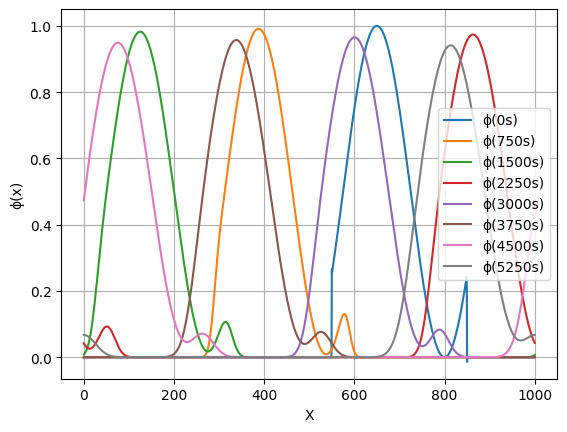

In [ ]:
#Exercise on Advection-Diffusion
import numpy as np
from matplotlib import pyplot as plt

def phi0(x): #phi(x,0)
    if (550<=x<850):
        return (np.sin(np.pi*(x-500.0)/300.))**2
    else:
        return 0.0

def ftcs_diff(p_now): #forward in time, centered in space + diffusion
    return p_now-0.5*c*(np.roll(p_now,-1)-np.roll(p_now,1))+dc*(np.roll(p_now,-1)-2.0*p_now+np.roll(p_now,1))

def ctcs_diff(p_old,p_now): #leapfrog, centered in time, centered in space  diffusion
    return p_old-c*(np.roll(p_now,-1)-np.roll(p_now,1))+2.0*dc*(np.roll(p_old,-1)-2.0*p_old+np.roll(p_old,1))

K=0.054

xi=0.0
xf=1000.0
dx=0.5

u=-0.35
alpha=0 #0 without RAW filter
beta=0 #1 without RAW filter

t0=0.0
t1=6000.0

c=-0.3
dt=c*dx/u
dc=K*dt/(dx**2) #alpha

x=np.arange(xi,xf+dx,dx)
p_now=[phi0(a) for a in x]
p_now=np.array(p_now)
p_old=p_now.copy()
p_new=p_now.copy()

p_now=ftcs_diff(p_old) #only for initial time field
plt.plot(x, p_now, label='ϕ('+str(round(t0))+'s)')

t=t0+dt

while(t<=t1):
    if (round(t,1)%750.==0 and round(t,1)!=round(t-dt,1)):
        plt.plot(x, p_now, label='ϕ('+str(round(t))+'s)')
    p_new=ctcs_diff(p_old,p_now) #ctcs for rest of field
    d=alpha*(p_old+p_new-2.0*p_now) #RAW Filter displacement
    p_old=p_now+beta*d #RAW filter update
    p_now=p_new+(1-beta)*d #RAW filter update
    t=t+dt

plt.xlabel('X')
plt.ylabel('ϕ(x)')
plt.legend()
plt.grid(visible=True)
plt.show()

##(f) (2 pts) If you apply a time filter, what advantages would this provide to the accuracy of the numerical method used above? Explain.

**Answer:**

The general form of the numerical solution has a physical mode proportional to the exact solution and a computational mode that is an artifact of the numerical method and does not correspond to any solution of the original PDE.

This computational modecreates large oscillations in value, and hinders convergence into the true solution. Filters like the Robert-Asselin-William filter serve to decrease the amplitude of the computational mode, so that the scheme will better converge.

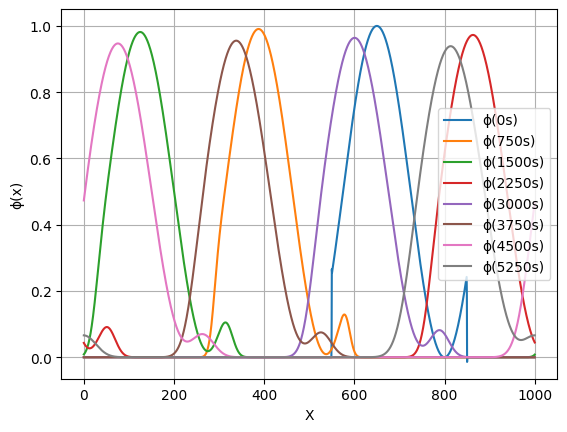

In [ ]:
#Exercise on Advection-Diffusion
import numpy as np
from matplotlib import pyplot as plt

def phi0(x): #phi(x,0)
    if (550<=x<850):
        return (np.sin(np.pi*(x-500.0)/300.))**2
    else:
        return 0.0

def ftcs_diff(p_now): #forward in time, centered in space + diffusion
    return p_now-0.5*c*(np.roll(p_now,-1)-np.roll(p_now,1))+dc*(np.roll(p_now,-1)-2.0*p_now+np.roll(p_now,1))

def ctcs_diff(p_old,p_now): #leapfrog, centered in time, centered in space  diffusion
    return p_old-c*(np.roll(p_now,-1)-np.roll(p_now,1))+2.0*dc*(np.roll(p_old,-1)-2.0*p_old+np.roll(p_old,1))

K=0.054

xi=0.0
xf=1000.0
dx=0.5

u=-0.35
alpha=0.1 #0 without RAW filter
beta=0.53 #1 without RAW filter

t0=0.0
t1=6000.0

c=-0.3
dt=c*dx/u
dc=K*dt/(dx**2) #alpha

x=np.arange(xi,xf+dx,dx)
p_now=[phi0(a) for a in x]
p_now=np.array(p_now)
p_old=p_now.copy()
p_new=p_now.copy()

p_now=ftcs_diff(p_old) #only for initial time field
plt.plot(x, p_now, label='ϕ('+str(round(t0))+'s)')

t=t0+dt

while(t<=t1):
    if (round(t,1)%750.==0 and round(t,1)!=round(t-dt,1)):
        plt.plot(x, p_now, label='ϕ('+str(round(t))+'s)')
    p_new=ctcs_diff(p_old,p_now) #ctcs for rest of field
    d=alpha*(p_old+p_new-2.0*p_now) #RAW Filter displacement
    p_old=p_now+beta*d #RAW filter update
    p_now=p_new+(1-beta)*d #RAW filter update
    t=t+dt

plt.xlabel('X')
plt.ylabel('ϕ(x)')
plt.legend()
plt.grid(visible=True)
plt.show()